# Data Aquisition

This notebook describes the process of acquiring data. <br/>
First we will acquire the data of the indexes NASDAQ-100 and VIX. Afterwards we will retrieve the macroeconomic data from the FRED API.




In [2]:
import yfinance as yf

In [3]:
target = 'AAPL'

params = {
    # 'tickers': f'^{target},^VIX,DX-Y.NYB',
    'tickers': 'AAPL',
    'interval': '1d',
    'rounding': True,
    'auto_adjust': True,
    'prepost': True,
    'start': '2009-01-01',
    'end': '2025-01-31'
}

data = yf.download(**params)
data.rename(columns={f'^{target}': target, '^VIX': 'VIX'}, inplace=True)

[*********************100%***********************]  1 of 1 completed


In [4]:
display(data.head(10))
display(data.tail(10))

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2009-01-02,2.72,2.73,2.55,2.58,746015200
2009-01-05,2.84,2.88,2.78,2.79,1181608400
2009-01-06,2.79,2.91,2.77,2.88,1289310400
2009-01-07,2.73,2.77,2.71,2.75,753048800
2009-01-08,2.78,2.79,2.70,2.71,673500800
2009-01-09,2.72,2.80,2.70,2.80,546845600
2009-01-12,2.66,2.73,2.63,2.71,617716400
2009-01-13,2.63,2.69,2.59,2.65,798397600


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-01-16,227.23,236.94,227.00,236.28,71759100
2025-01-17,228.94,231.24,227.45,231.07,68488300
2025-01-21,221.64,223.41,218.39,222.99,98070400
2025-01-22,222.82,223.11,218.80,218.80,64126500
2025-01-23,222.65,226.01,221.30,223.73,60234800
2025-01-24,221.78,224.61,220.41,223.77,54697900
2025-01-27,228.83,231.10,222.97,223.01,94863400
2025-01-28,237.19,239.11,229.77,229.81,75707600


In [74]:
import fredapi
from dotenv import load_dotenv
import pandas as pd
import os

In [75]:
load_dotenv()
fred_api_key = os.getenv("FRED_API_KEY")

Fred = fredapi.Fred(api_key=fred_api_key)

In [76]:
indicators = {
    "cpi": "CPIAUCSL", # Consumer Price Index - monthly
    "rate": "EFFR",  # Interest Rate - business days
    "ppi": "PPIACO", # Producer Price Index - monthly
    "gdp": "GDP", # Gross domestic product - quarterly
    "unrate": "UNRATE",  # Unemplyment Rate - monthly
    "CSI": "UMCSENT",  # Consumer Sentiment Index - monthly
    "HS": "HOUST",  # Housing Starts - monthly
}


In [77]:
def forward_fill_to_daily(s: pd.Series) -> pd.Series:
    # fill all days before adjusting to business days, otherwise published indicator values might be cut
    idx = pd.date_range(params["start"], params["end"], freq="D")
    s = s.reindex(index=idx)
    s.ffill(inplace=True)
    idx = pd.date_range(params["start"], params["end"], freq="B")
    s = s.reindex(index=idx)

    return s

In [78]:
indicator_data = {}

for name, series_id in indicators.items():
    indicator_data[name] = Fred.get_series(series_id=series_id, observation_start=params["start"],
                                           observation_end=params["end"])
    indicator_data[name] = forward_fill_to_daily(indicator_data[name])

In [79]:
df = pd.concat(indicator_data, axis=1)
df.columns = pd.MultiIndex.from_product([['MACRO'], df.columns])  # make multiIndex just like nasdaq/vix data

df

MACRO                                             
                cpi  rate    ppi        gdp unrate   CSI      HS
2005-01-03  191.600  2.31  150.9  12767.286    5.3  95.5  2144.0
2005-01-04  191.600  2.25  150.9  12767.286    5.3  95.5  2144.0
2005-01-05  191.600  2.25  150.9  12767.286    5.3  95.5  2144.0
2005-01-06  191.600  2.25  150.9  12767.286    5.3  95.5  2144.0
2005-01-07  191.600  2.24  150.9  12767.286    5.3  95.5  2144.0
...             ...   ...    ...        ...    ...   ...     ...
2019-12-26  258.630  1.55  199.0  21933.217    3.6  99.3  1548.0
2019-12-27  258.630  1.55  199.0  21933.217    3.6  99.3  1548.0
2019-12-30  258.630  1.55  199.0  21933.217    3.6  99.3  1548.0
2019-12-31  258.630  1.55  199.0  21933.217    3.6  99.3  1548.0
2020-01-01  259.127  1.55  199.3  21751.238    3.6  99.8  1581.0

[3913 rows x 7 columns]

In [80]:
data

Price         Close                     High                      Low  \
Ticker     DX-Y.NYB      NDX    VIX DX-Y.NYB      NDX    VIX DX-Y.NYB   
Date                                                                    
2005-01-03    81.30  1603.51  14.08    81.76  1635.45  14.23    80.77   
2005-01-04    82.57  1571.83  13.98    82.71  1612.78  14.45    81.18   
2005-01-05    82.54  1563.76  14.09    82.92  1580.88  14.09    82.30   
2005-01-06    83.15  1557.52  13.58    83.23  1570.75  14.09    82.43   
2005-01-07    83.61  1564.81  13.49    83.79  1577.76  13.51    82.61   
...             ...      ...    ...      ...      ...    ...      ...   
2019-12-24    97.65  8699.51  12.67    97.80  8708.22  12.84    97.62   
2019-12-26    97.59  8778.31  12.65    97.71  8778.33  12.75    97.49   
2019-12-27    96.92  8770.98  13.43    97.55  8811.10  13.72    96.92   
2019-12-30    96.74  8709.73  14.82    97.00  8768.30  15.14    96.61   
2019-12-31    96.39  8733.07  13.78    96.73  8735.43  15.39    96.36   

Price                          Open                   Volume                \
Ticker          NDX    VIX DX-Y.NYB      NDX    VIX DX-Y.NYB           NDX   
Date                                                                         
2005-01-03  1598.79  13.25    81.05  1628.75  13.39      0.0  2.193130e+09   
2005-01-04  1565.02  13.93    81.36  1611.22  14.01      0.0  2.690460e+09   
2005-01-05  1562.64  13.26    82.49  1568.68  13.98      0.0  2.375380e+09   
2005-01-06  1556.84  13.33    82.45  1567.66  14.09      0.0  2.174220e+09   
2005-01-07  1551.29  12.94    83.07  1565.63  13.47      0.0  2.191910e+09   
...             ...    ...      ...      ...    ...      ...           ...   
2019-12-24  8684.12  12.56    97.66  8705.30  12.65      0.0  1.014530e+09   
2019-12-26  8716.03  11.72    97.63  8717.95  12.74      0.0  1.639960e+09   
2019-12-27  8749.86  11.89    97.54  8805.86  12.61      0.0  1.833740e+09   
2019-12-30  8671.92  13.44    97.00  8766.39  13.74      0.0  2.051320e+09   
2019-12-31  8674.38  13.75    96.73  8681.33  14.84      0.0  2.186830e+09   

Price            
Ticker      VIX  
Date             
2005-01-03  0.0  
2005-01-04  0.0  
2005-01-05  0.0  
2005-01-06  0.0  
2005-01-07  0.0  
...         ...  
2019-12-24  0.0  
2019-12-26  0.0  
2019-12-27  0.0  
2019-12-30  0.0  
2019-12-31  0.0  

[3781 rows x 15 columns]

In [81]:
data_null = data.isnull()
data_null

Price         Close                   High                    Low         \
Ticker     DX-Y.NYB    NDX    VIX DX-Y.NYB    NDX    VIX DX-Y.NYB    NDX   
Date                                                                       
2005-01-03    False  False  False    False  False  False    False  False   
2005-01-04    False  False  False    False  False  False    False  False   
2005-01-05    False  False  False    False  False  False    False  False   
2005-01-06    False  False  False    False  False  False    False  False   
2005-01-07    False  False  False    False  False  False    False  False   
...             ...    ...    ...      ...    ...    ...      ...    ...   
2019-12-24    False  False  False    False  False  False    False  False   
2019-12-26    False  False  False    False  False  False    False  False   
2019-12-27    False  False  False    False  False  False    False  False   
2019-12-30    False  False  False    False  False  False    False  False   
2019-12-31    False  False  False    False  False  False    False  False   

Price                 Open                 Volume                
Ticker        VIX DX-Y.NYB    NDX    VIX DX-Y.NYB    NDX    VIX  
Date                                                             
2005-01-03  False    False  False  False    False  False  False  
2005-01-04  False    False  False  False    False  False  False  
2005-01-05  False    False  False  False    False  False  False  
2005-01-06  False    False  False  False    False  False  False  
2005-01-07  False    False  False  False    False  False  False  
...           ...      ...    ...    ...      ...    ...    ...  
2019-12-24  False    False  False  False    False  False  False  
2019-12-26  False    False  False  False    False  False  False  
2019-12-27  False    False  False  False    False  False  False  
2019-12-30  False    False  False  False    False  False  False  
2019-12-31  False    False  False  False    False  False  False  

[3781 rows x 15 columns]

In [82]:
data.dropna(inplace=True)
data

Price         Close                     High                      Low  \
Ticker     DX-Y.NYB      NDX    VIX DX-Y.NYB      NDX    VIX DX-Y.NYB   
Date                                                                    
2005-01-03    81.30  1603.51  14.08    81.76  1635.45  14.23    80.77   
2005-01-04    82.57  1571.83  13.98    82.71  1612.78  14.45    81.18   
2005-01-05    82.54  1563.76  14.09    82.92  1580.88  14.09    82.30   
2005-01-06    83.15  1557.52  13.58    83.23  1570.75  14.09    82.43   
2005-01-07    83.61  1564.81  13.49    83.79  1577.76  13.51    82.61   
...             ...      ...    ...      ...      ...    ...      ...   
2019-12-24    97.65  8699.51  12.67    97.80  8708.22  12.84    97.62   
2019-12-26    97.59  8778.31  12.65    97.71  8778.33  12.75    97.49   
2019-12-27    96.92  8770.98  13.43    97.55  8811.10  13.72    96.92   
2019-12-30    96.74  8709.73  14.82    97.00  8768.30  15.14    96.61   
2019-12-31    96.39  8733.07  13.78    96.73  8735.43  15.39    96.36   

Price                          Open                   Volume                \
Ticker          NDX    VIX DX-Y.NYB      NDX    VIX DX-Y.NYB           NDX   
Date                                                                         
2005-01-03  1598.79  13.25    81.05  1628.75  13.39      0.0  2.193130e+09   
2005-01-04  1565.02  13.93    81.36  1611.22  14.01      0.0  2.690460e+09   
2005-01-05  1562.64  13.26    82.49  1568.68  13.98      0.0  2.375380e+09   
2005-01-06  1556.84  13.33    82.45  1567.66  14.09      0.0  2.174220e+09   
2005-01-07  1551.29  12.94    83.07  1565.63  13.47      0.0  2.191910e+09   
...             ...    ...      ...      ...    ...      ...           ...   
2019-12-24  8684.12  12.56    97.66  8705.30  12.65      0.0  1.014530e+09   
2019-12-26  8716.03  11.72    97.63  8717.95  12.74      0.0  1.639960e+09   
2019-12-27  8749.86  11.89    97.54  8805.86  12.61      0.0  1.833740e+09   
2019-12-30  8671.92  13.44    97.00  8766.39  13.74      0.0  2.051320e+09   
2019-12-31  8674.38  13.75    96.73  8681.33  14.84      0.0  2.186830e+09   

Price            
Ticker      VIX  
Date             
2005-01-03  0.0  
2005-01-04  0.0  
2005-01-05  0.0  
2005-01-06  0.0  
2005-01-07  0.0  
...         ...  
2019-12-24  0.0  
2019-12-26  0.0  
2019-12-27  0.0  
2019-12-30  0.0  
2019-12-31  0.0  

[3773 rows x 15 columns]

In [83]:
import numpy as np
import pandas as pd

def calculate_ema(data, window):
    return data.ewm(span=window, adjust=False).mean()


def add_macd(df, symbol, short_window=12, long_window=26, signal_window=9):
    data = df[('Close', symbol)]
    short_ema = calculate_ema(data, short_window)
    long_ema = calculate_ema(data, long_window)
    macd = short_ema - long_ema
    signal = calculate_ema(macd, signal_window)

    df[("MACD", symbol)] = macd
    df[("MACD_signal", symbol)] = signal
    return df


def add_rsi(df, symbol, window=14):
    data = df[('Close', symbol)]
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    df[("RSI", symbol)] = rsi
    return df


def add_atr(df, symbol, high="High", low="Low", close="Close", period=14):
    h = df[(high, symbol)]
    l = df[(low, symbol)]
    c = df[(close, symbol)]

    tr1 = h - l
    tr2 = (h - c.shift()).abs()
    tr3 = (l - c.shift()).abs()

    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.rolling(window=period).mean()

    df[("ATR", symbol)] = atr
    return df


data = add_macd(data, target, 12, 26, 9)
data = add_rsi(data, target, window=14)
data = add_atr(data, target)
data


Price         Close                     High                      Low  \
Ticker     DX-Y.NYB      NDX    VIX DX-Y.NYB      NDX    VIX DX-Y.NYB   
Date                                                                    
2005-01-03    81.30  1603.51  14.08    81.76  1635.45  14.23    80.77   
2005-01-04    82.57  1571.83  13.98    82.71  1612.78  14.45    81.18   
2005-01-05    82.54  1563.76  14.09    82.92  1580.88  14.09    82.30   
2005-01-06    83.15  1557.52  13.58    83.23  1570.75  14.09    82.43   
2005-01-07    83.61  1564.81  13.49    83.79  1577.76  13.51    82.61   
...             ...      ...    ...      ...      ...    ...      ...   
2019-12-24    97.65  8699.51  12.67    97.80  8708.22  12.84    97.62   
2019-12-26    97.59  8778.31  12.65    97.71  8778.33  12.75    97.49   
2019-12-27    96.92  8770.98  13.43    97.55  8811.10  13.72    96.92   
2019-12-30    96.74  8709.73  14.82    97.00  8768.30  15.14    96.61   
2019-12-31    96.39  8733.07  13.78    96.73  8735.43  15.39    96.36   

Price                          Open                   Volume                \
Ticker          NDX    VIX DX-Y.NYB      NDX    VIX DX-Y.NYB           NDX   
Date                                                                         
2005-01-03  1598.79  13.25    81.05  1628.75  13.39      0.0  2.193130e+09   
2005-01-04  1565.02  13.93    81.36  1611.22  14.01      0.0  2.690460e+09   
2005-01-05  1562.64  13.26    82.49  1568.68  13.98      0.0  2.375380e+09   
2005-01-06  1556.84  13.33    82.45  1567.66  14.09      0.0  2.174220e+09   
2005-01-07  1551.29  12.94    83.07  1565.63  13.47      0.0  2.191910e+09   
...             ...    ...      ...      ...    ...      ...           ...   
2019-12-24  8684.12  12.56    97.66  8705.30  12.65      0.0  1.014530e+09   
2019-12-26  8716.03  11.72    97.63  8717.95  12.74      0.0  1.639960e+09   
2019-12-27  8749.86  11.89    97.54  8805.86  12.61      0.0  1.833740e+09   
2019-12-30  8671.92  13.44    97.00  8766.39  13.74      0.0  2.051320e+09   
2019-12-31  8674.38  13.75    96.73  8681.33  14.84      0.0  2.186830e+09   

Price                  MACD MACD_signal        RSI        ATR  
Ticker      VIX         NDX         NDX        NDX        NDX  
Date                                                           
2005-01-03  0.0    0.000000    0.000000        NaN        NaN  
2005-01-04  0.0   -2.527179   -0.505436        NaN        NaN  
2005-01-05  0.0   -5.122124   -1.428774        NaN        NaN  
2005-01-06  0.0   -7.594607   -2.661940        NaN        NaN  
2005-01-07  0.0   -8.863650   -3.902282        NaN        NaN  
...         ...         ...         ...        ...        ...  
2019-12-24  0.0  120.909659  101.662408  91.192706  59.317143  
2019-12-26  0.0  128.732565  107.076439  92.252774  61.492857  
2019-12-27  0.0  132.809855  112.223122  89.374618  58.906429  
2019-12-30  0.0  129.604770  115.699452  84.626285  61.275000  
2019-12-31  0.0  127.478567  118.055275  86.707757  61.812857  

[3773 rows x 19 columns]

In [84]:
# Drop first 13 days, where RSI and ATR are NaN
data.dropna(inplace=True)
data

Price         Close                     High                      Low  \
Ticker     DX-Y.NYB      NDX    VIX DX-Y.NYB      NDX    VIX DX-Y.NYB   
Date                                                                    
2005-01-21    83.26  1503.64  14.36    84.00  1524.03  14.46    83.18   
2005-01-24    83.24  1480.66  14.65    83.49  1509.83  14.75    83.01   
2005-01-25    83.99  1490.57  14.06    84.08  1505.05  14.36    83.21   
2005-01-26    83.30  1509.01  13.44    83.95  1513.44  13.84    83.08   
2005-01-27    83.43  1507.55  13.24    83.61  1512.74  13.57    83.04   
...             ...      ...    ...      ...      ...    ...      ...   
2019-12-24    97.65  8699.51  12.67    97.80  8708.22  12.84    97.62   
2019-12-26    97.59  8778.31  12.65    97.71  8778.33  12.75    97.49   
2019-12-27    96.92  8770.98  13.43    97.55  8811.10  13.72    96.92   
2019-12-30    96.74  8709.73  14.82    97.00  8768.30  15.14    96.61   
2019-12-31    96.39  8733.07  13.78    96.73  8735.43  15.39    96.36   

Price                          Open                   Volume                \
Ticker          NDX    VIX DX-Y.NYB      NDX    VIX DX-Y.NYB           NDX   
Date                                                                         
2005-01-21  1502.48  13.40    83.83  1519.30  13.75      0.0  2.043770e+09   
2005-01-24  1480.66  14.17    83.15  1507.79  14.38      0.0  2.134680e+09   
2005-01-25  1488.60  13.88    83.33  1492.65  14.34      0.0  2.003630e+09   
2005-01-26  1495.31  13.06    83.95  1502.05  13.84      0.0  2.105070e+09   
2005-01-27  1497.36  12.96    83.27  1505.25  13.50      0.0  2.106220e+09   
...             ...    ...      ...      ...    ...      ...           ...   
2019-12-24  8684.12  12.56    97.66  8705.30  12.65      0.0  1.014530e+09   
2019-12-26  8716.03  11.72    97.63  8717.95  12.74      0.0  1.639960e+09   
2019-12-27  8749.86  11.89    97.54  8805.86  12.61      0.0  1.833740e+09   
2019-12-30  8671.92  13.44    97.00  8766.39  13.74      0.0  2.051320e+09   
2019-12-31  8674.38  13.75    96.73  8681.33  14.84      0.0  2.186830e+09   

Price                  MACD MACD_signal        RSI        ATR  
Ticker      VIX         NDX         NDX        NDX        NDX  
Date                                                           
2005-01-21  0.0  -18.855812  -12.838904  24.529457  25.155714  
2005-01-24  0.0  -22.973615  -14.865846  21.955896  24.620714  
2005-01-25  0.0  -25.147465  -16.922170  29.402819  22.951429  
2005-01-26  0.0  -25.093046  -18.556345  36.815489  23.282143  
2005-01-27  0.0  -24.880917  -19.821260  37.683017  23.387143  
...         ...         ...         ...        ...        ...  
2019-12-24  0.0  120.909659  101.662408  91.192706  59.317143  
2019-12-26  0.0  128.732565  107.076439  92.252774  61.492857  
2019-12-27  0.0  132.809855  112.223122  89.374618  58.906429  
2019-12-30  0.0  129.604770  115.699452  84.626285  61.275000  
2019-12-31  0.0  127.478567  118.055275  86.707757  61.812857  

[3760 rows x 19 columns]

In [85]:
df

MACRO                                             
                cpi  rate    ppi        gdp unrate   CSI      HS
2005-01-03  191.600  2.31  150.9  12767.286    5.3  95.5  2144.0
2005-01-04  191.600  2.25  150.9  12767.286    5.3  95.5  2144.0
2005-01-05  191.600  2.25  150.9  12767.286    5.3  95.5  2144.0
2005-01-06  191.600  2.25  150.9  12767.286    5.3  95.5  2144.0
2005-01-07  191.600  2.24  150.9  12767.286    5.3  95.5  2144.0
...             ...   ...    ...        ...    ...   ...     ...
2019-12-26  258.630  1.55  199.0  21933.217    3.6  99.3  1548.0
2019-12-27  258.630  1.55  199.0  21933.217    3.6  99.3  1548.0
2019-12-30  258.630  1.55  199.0  21933.217    3.6  99.3  1548.0
2019-12-31  258.630  1.55  199.0  21933.217    3.6  99.3  1548.0
2020-01-01  259.127  1.55  199.3  21751.238    3.6  99.8  1581.0

[3913 rows x 7 columns]

In [86]:
data_full = data.join(df, how='inner')
data_full.columns = pd.MultiIndex.from_tuples([
    (lvl1, lvl2.lstrip("^")) for lvl1, lvl2 in data_full.columns
])

data_full

Close                     High                      Low  \
           DX-Y.NYB      NDX    VIX DX-Y.NYB      NDX    VIX DX-Y.NYB   
2005-01-21    83.26  1503.64  14.36    84.00  1524.03  14.46    83.18   
2005-01-24    83.24  1480.66  14.65    83.49  1509.83  14.75    83.01   
2005-01-25    83.99  1490.57  14.06    84.08  1505.05  14.36    83.21   
2005-01-26    83.30  1509.01  13.44    83.95  1513.44  13.84    83.08   
2005-01-27    83.43  1507.55  13.24    83.61  1512.74  13.57    83.04   
...             ...      ...    ...      ...      ...    ...      ...   
2019-12-24    97.65  8699.51  12.67    97.80  8708.22  12.84    97.62   
2019-12-26    97.59  8778.31  12.65    97.71  8778.33  12.75    97.49   
2019-12-27    96.92  8770.98  13.43    97.55  8811.10  13.72    96.92   
2019-12-30    96.74  8709.73  14.82    97.00  8768.30  15.14    96.61   
2019-12-31    96.39  8733.07  13.78    96.73  8735.43  15.39    96.36   

                               Open  ... MACD_signal        RSI        ATR  \
                NDX    VIX DX-Y.NYB  ...         NDX        NDX        NDX   
2005-01-21  1502.48  13.40    83.83  ...  -12.838904  24.529457  25.155714   
2005-01-24  1480.66  14.17    83.15  ...  -14.865846  21.955896  24.620714   
2005-01-25  1488.60  13.88    83.33  ...  -16.922170  29.402819  22.951429   
2005-01-26  1495.31  13.06    83.95  ...  -18.556345  36.815489  23.282143   
2005-01-27  1497.36  12.96    83.27  ...  -19.821260  37.683017  23.387143   
...             ...    ...      ...  ...         ...        ...        ...   
2019-12-24  8684.12  12.56    97.66  ...  101.662408  91.192706  59.317143   
2019-12-26  8716.03  11.72    97.63  ...  107.076439  92.252774  61.492857   
2019-12-27  8749.86  11.89    97.54  ...  112.223122  89.374618  58.906429   
2019-12-30  8671.92  13.44    97.00  ...  115.699452  84.626285  61.275000   
2019-12-31  8674.38  13.75    96.73  ...  118.055275  86.707757  61.812857   

             MACRO                                               
               cpi  rate    ppi        gdp unrate   CSI      HS  
2005-01-21  191.60  2.26  150.9  12767.286    5.3  95.5  2144.0  
2005-01-24  191.60  2.26  150.9  12767.286    5.3  95.5  2144.0  
2005-01-25  191.60  2.29  150.9  12767.286    5.3  95.5  2144.0  
2005-01-26  191.60  2.33  150.9  12767.286    5.3  95.5  2144.0  
2005-01-27  191.60  2.39  150.9  12767.286    5.3  95.5  2144.0  
...            ...   ...    ...        ...    ...   ...     ...  
2019-12-24  258.63  1.55  199.0  21933.217    3.6  99.3  1548.0  
2019-12-26  258.63  1.55  199.0  21933.217    3.6  99.3  1548.0  
2019-12-27  258.63  1.55  199.0  21933.217    3.6  99.3  1548.0  
2019-12-30  258.63  1.55  199.0  21933.217    3.6  99.3  1548.0  
2019-12-31  258.63  1.55  199.0  21933.217    3.6  99.3  1548.0  

[3760 rows x 26 columns]

In [92]:
data.drop([('Volume', 'DX-Y.NYB'), ('Volume', 'VIX')], axis=1, inplace=True)

In [93]:
data

Price         Close                     High                      Low  \
Ticker     DX-Y.NYB      NDX    VIX DX-Y.NYB      NDX    VIX DX-Y.NYB   
Date                                                                    
2005-01-21    83.26  1503.64  14.36    84.00  1524.03  14.46    83.18   
2005-01-24    83.24  1480.66  14.65    83.49  1509.83  14.75    83.01   
2005-01-25    83.99  1490.57  14.06    84.08  1505.05  14.36    83.21   
2005-01-26    83.30  1509.01  13.44    83.95  1513.44  13.84    83.08   
2005-01-27    83.43  1507.55  13.24    83.61  1512.74  13.57    83.04   
...             ...      ...    ...      ...      ...    ...      ...   
2019-12-24    97.65  8699.51  12.67    97.80  8708.22  12.84    97.62   
2019-12-26    97.59  8778.31  12.65    97.71  8778.33  12.75    97.49   
2019-12-27    96.92  8770.98  13.43    97.55  8811.10  13.72    96.92   
2019-12-30    96.74  8709.73  14.82    97.00  8768.30  15.14    96.61   
2019-12-31    96.39  8733.07  13.78    96.73  8735.43  15.39    96.36   

Price                          Open                        Volume        MACD  \
Ticker          NDX    VIX DX-Y.NYB      NDX    VIX           NDX         NDX   
Date                                                                            
2005-01-21  1502.48  13.40    83.83  1519.30  13.75  2.043770e+09  -18.855812   
2005-01-24  1480.66  14.17    83.15  1507.79  14.38  2.134680e+09  -22.973615   
2005-01-25  1488.60  13.88    83.33  1492.65  14.34  2.003630e+09  -25.147465   
2005-01-26  1495.31  13.06    83.95  1502.05  13.84  2.105070e+09  -25.093046   
2005-01-27  1497.36  12.96    83.27  1505.25  13.50  2.106220e+09  -24.880917   
...             ...    ...      ...      ...    ...           ...         ...   
2019-12-24  8684.12  12.56    97.66  8705.30  12.65  1.014530e+09  120.909659   
2019-12-26  8716.03  11.72    97.63  8717.95  12.74  1.639960e+09  128.732565   
2019-12-27  8749.86  11.89    97.54  8805.86  12.61  1.833740e+09  132.809855   
2019-12-30  8671.92  13.44    97.00  8766.39  13.74  2.051320e+09  129.604770   
2019-12-31  8674.38  13.75    96.73  8681.33  14.84  2.186830e+09  127.478567   

Price      MACD_signal        RSI        ATR  
Ticker             NDX        NDX        NDX  
Date                                          
2005-01-21  -12.838904  24.529457  25.155714  
2005-01-24  -14.865846  21.955896  24.620714  
2005-01-25  -16.922170  29.402819  22.951429  
2005-01-26  -18.556345  36.815489  23.282143  
2005-01-27  -19.821260  37.683017  23.387143  
...                ...        ...        ...  
2019-12-24  101.662408  91.192706  59.317143  
2019-12-26  107.076439  92.252774  61.492857  
2019-12-27  112.223122  89.374618  58.906429  
2019-12-30  115.699452  84.626285  61.275000  
2019-12-31  118.055275  86.707757  61.812857  

[3760 rows x 17 columns]

In [5]:

data_full = data

In [6]:
data_full.to_csv(f"./data/{target}_data.csv", index=True, encoding="utf-8")

In [88]:
data_full.columns = ['_'.join(col).strip() for col in data_full.columns]

            Close_DX-Y.NYB  Close_NDX  Close_VIX  High_DX-Y.NYB  High_NDX  \
2005-01-21           83.26    1503.64      14.36          84.00   1524.03   
2005-01-24           83.24    1480.66      14.65          83.49   1509.83   
2005-01-25           83.99    1490.57      14.06          84.08   1505.05   
2005-01-26           83.30    1509.01      13.44          83.95   1513.44   
2005-01-27           83.43    1507.55      13.24          83.61   1512.74   

            High_VIX  Low_DX-Y.NYB  Low_NDX  Low_VIX  Open_DX-Y.NYB  ...  \
2005-01-21     14.46         83.18  1502.48    13.40          83.83  ...   
2005-01-24     14.75         83.01  1480.66    14.17          83.15  ...   
2005-01-25     14.36         83.21  1488.60    13.88          83.33  ...   
2005-01-26     13.84         83.08  1495.31    13.06          83.95  ...   
2005-01-27     13.57         83.04  1497.36    12.96          83.27  ...   

            MACD_signal_NDX    RSI_NDX    ATR_NDX  MACRO_cpi  MACRO_rate  \
2005

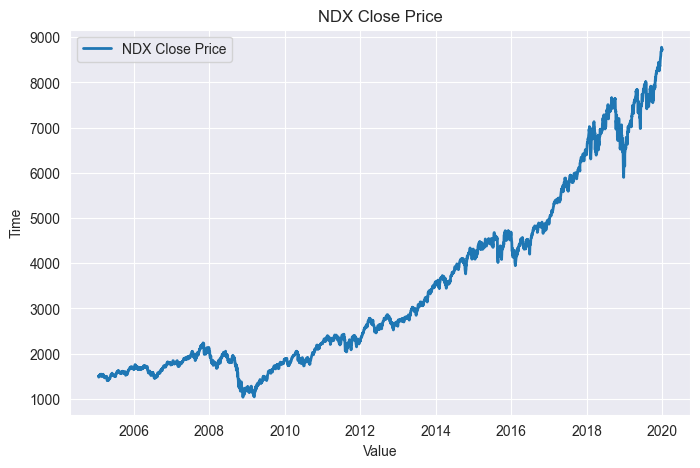

In [89]:
from matplotlib import pyplot as plt

print(data_full.head())

plt.figure(figsize=(8, 5))
plt.plot(data_full[[f"Close_{target}"]], label=f'{target} Close Price', linewidth=2)
plt.title(f"{target} Close Price")
plt.xlabel("Value")
plt.ylabel("Time")
plt.legend()
plt.grid(True)
plt.show()

Creating a grid of plots for each column in the dataset

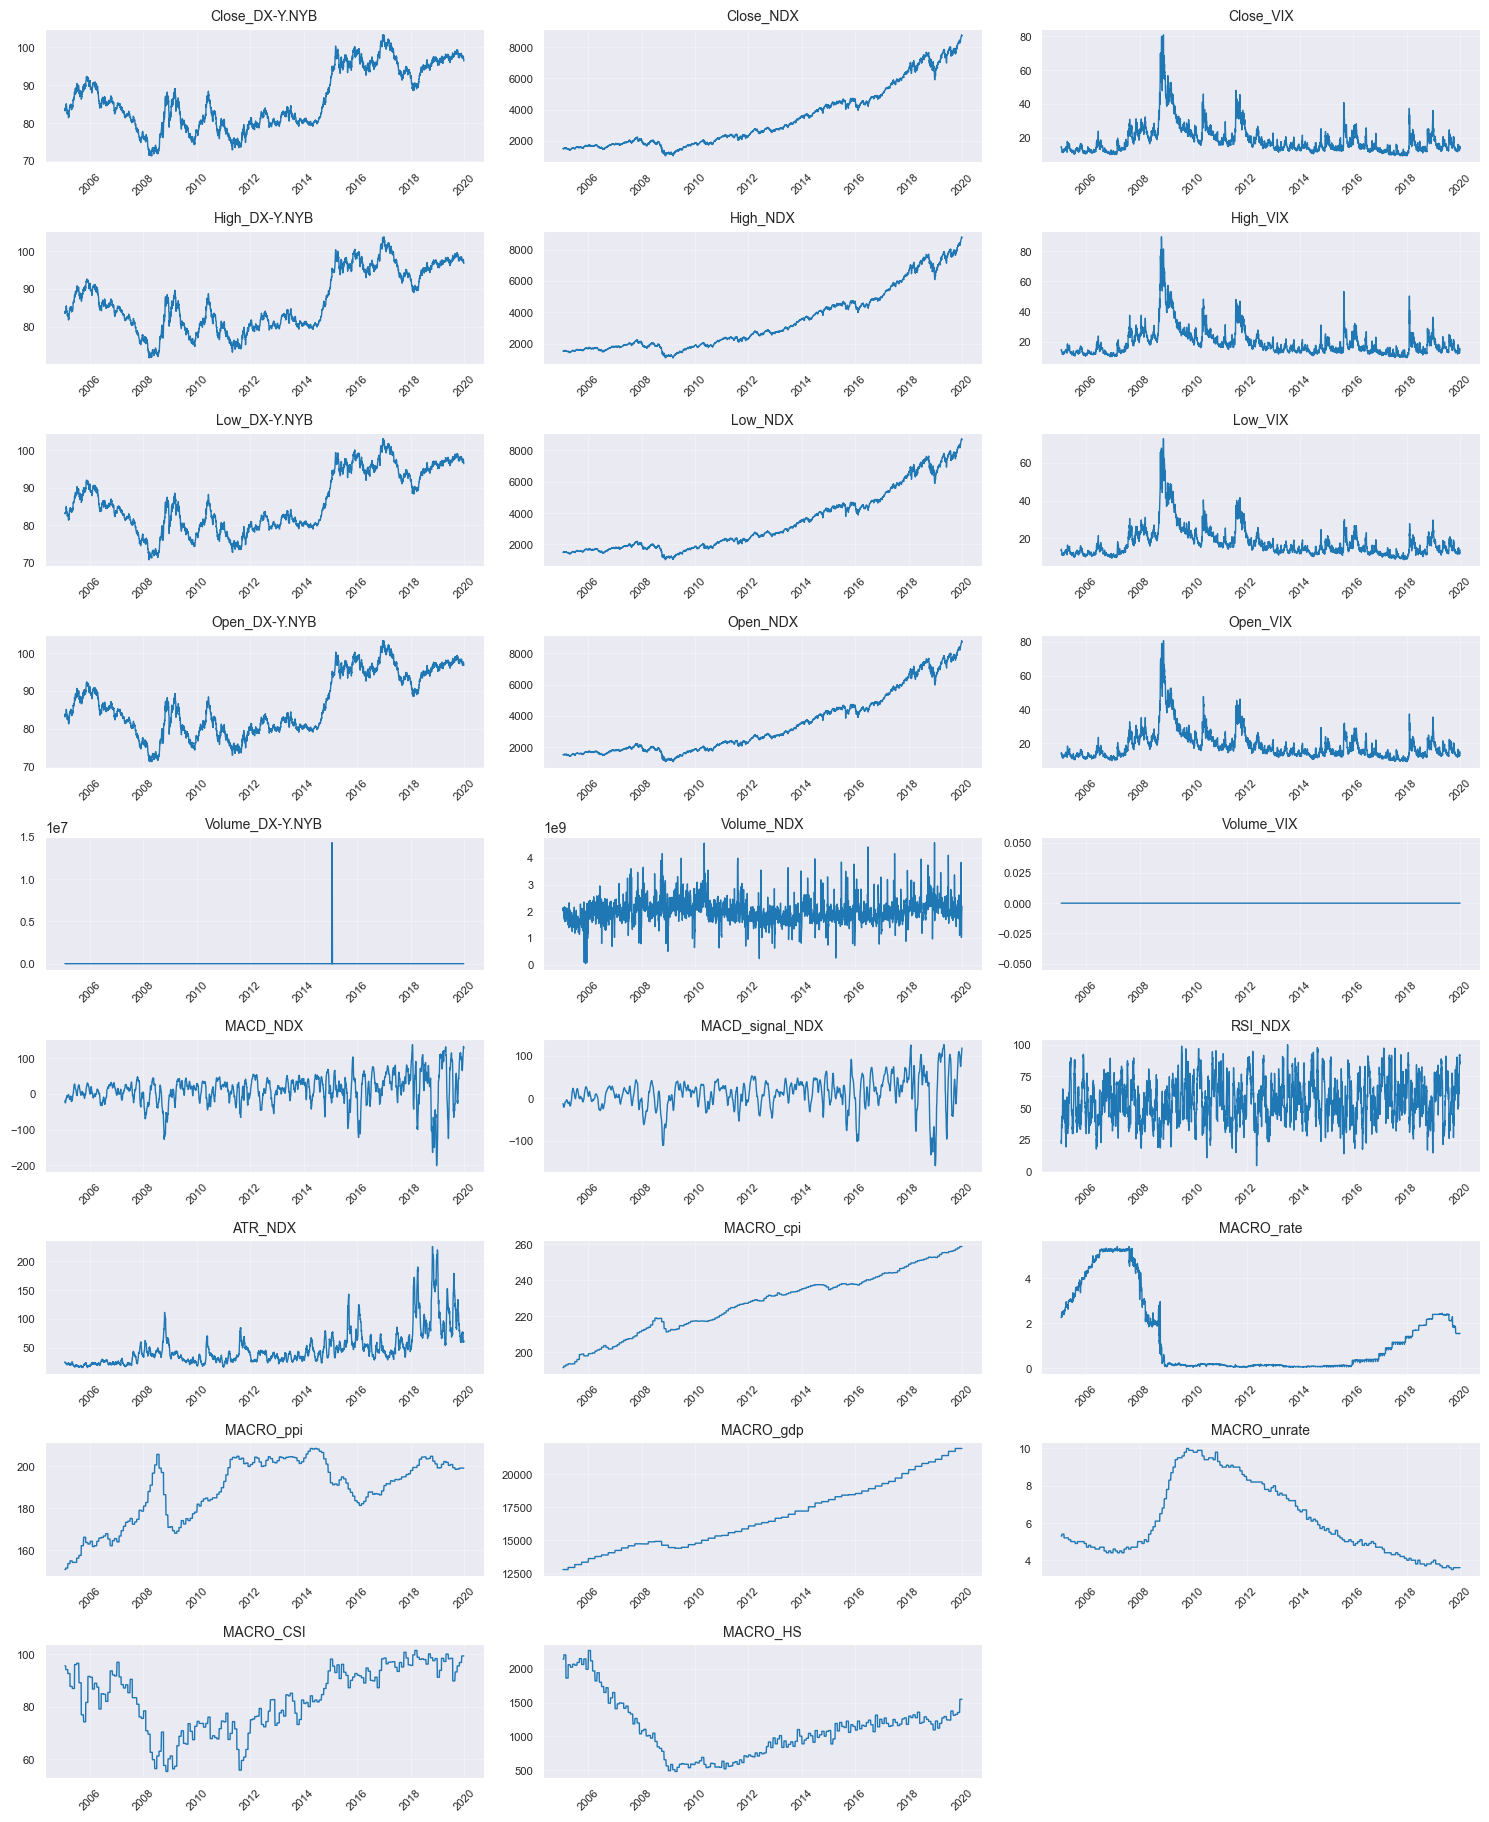

In [90]:
fig, axes = plt.subplots(nrows=10, ncols=3, figsize=(15, 20))
axes = axes.flatten()

for idx, col in enumerate(data_full.columns):
    axes[idx].plot(data_full.index, data_full[col], linewidth=1)
    axes[idx].set_title(col, fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45, labelsize=8)
    axes[idx].tick_params(axis='y', labelsize=8)

for idx in range(len(data_full.columns), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()
